# Part 1 – Data Exploration

This section presents descriptive statistics and visualizations based on the MovieLens ratings dataset.

## 1. Load and Preview the Dataset

The dataset contains user ratings for movies, including `userId`, `movieId`, `rating`, and `timestamp`.

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("MovieLens-Ratings.csv")

# Preview the dataset
print(df.head())

   userId  movieId  rating   timestamp
0       1      307     3.5  1256677221
1       1      481     3.5  1256677456
2       1     1091     1.5  1256677471
3       1     1257     4.5  1256677460
4       1     1449     4.5  1256677264


## 2. Overview and Descriptive Statistics
Displays dataset dimensions, basic statistics, and the number of unique users and movies.

In [101]:
print("\nShape:", df.shape)
print("\nInfo:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

n_users = df['userId'].nunique()
n_movies = df['movieId'].nunique()
print(f"\nUnique users: {n_users}")
print(f"Unique movies: {n_movies}")


Shape: (27753444, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27753444 entries, 0 to 27753443
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 847.0 MB

Descriptive Statistics:
             userId       movieId        rating     timestamp
count  2.775344e+07  2.775344e+07  2.775344e+07  2.775344e+07
mean   1.419420e+05  1.848800e+04  3.530445e+00  1.193122e+09
std    8.170740e+04  3.510263e+04  1.066353e+00  2.160482e+08
min    1.000000e+00  1.000000e+00  5.000000e-01  7.896520e+08
25%    7.117600e+04  1.097000e+03  3.000000e+00  9.986053e+08
50%    1.420220e+05  2.716000e+03  3.500000e+00  1.174256e+09
75%    2.124590e+05  7.150000e+03  4.000000e+00  1.422744e+09
max    2.832280e+05  1.938860e+05  5.000000e+00  1.537945e+09

Unique users: 283228
Unique movies: 53889


### Check for Missing Values
Good practice to ensure data quality.

In [102]:
print(df.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


## 3. Rating Distribution
Visualizes how ratings are distributed on a 0.5 to 5.0 scale.

rating
0.5     442388
1.0     886233
1.5     441354
2.0    1850627
2.5    1373419
3.0    5515668
3.5    3404360
4.0    7394710
4.5    2373550
5.0    4071135
Name: count, dtype: int64


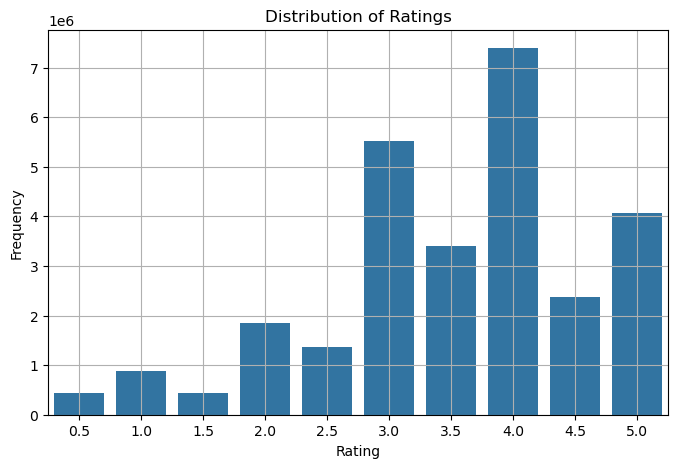

In [5]:
rating_counts = df['rating'].value_counts().sort_index()
print(rating_counts)

plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## 4. Ratings per User
Shows how many ratings each user provided.

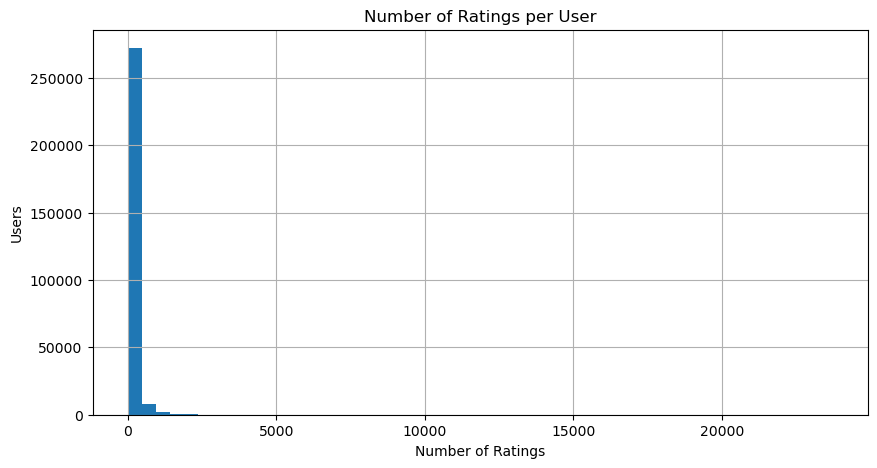

In [13]:
ratings_per_user = df.groupby('userId').size()
plt.figure(figsize=(10, 5))
ratings_per_user.hist(bins=50)
plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")
plt.grid(True)
plt.show()

## 5. Ratings per Movie
Displays how often each movie was rated.

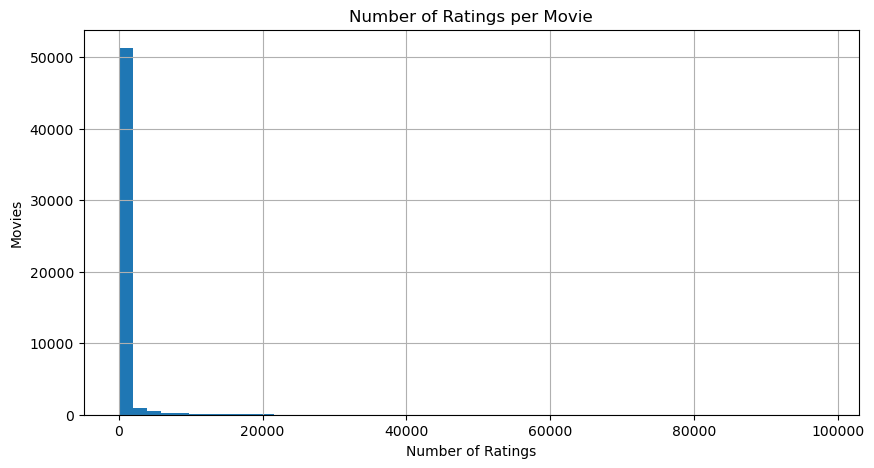

In [14]:
ratings_per_movie = df.groupby('movieId').size()
plt.figure(figsize=(10, 5))
ratings_per_movie.hist(bins=50)
plt.title("Number of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Movies")
plt.grid(True)
plt.show()

### Log-Scale Histogram for Ratings per Movie
Visualizes the skew more clearly.

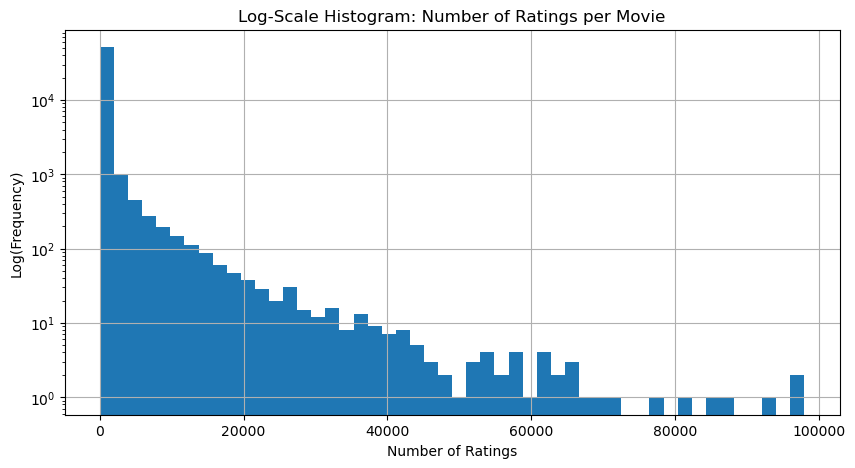

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(ratings_per_movie, bins=50, log=True)
plt.title("Log-Scale Histogram: Number of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Log(Frequency)")
plt.grid(True)
plt.show()

### Box Plot of Ratings per Movie
Summarizes distribution and outliers.

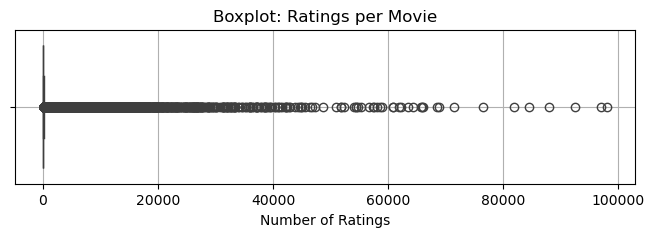

In [16]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=ratings_per_movie)
plt.title("Boxplot: Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.grid(True)
plt.show()

### Top 10 Most Rated Movies
Identifies movies with the most user interaction.

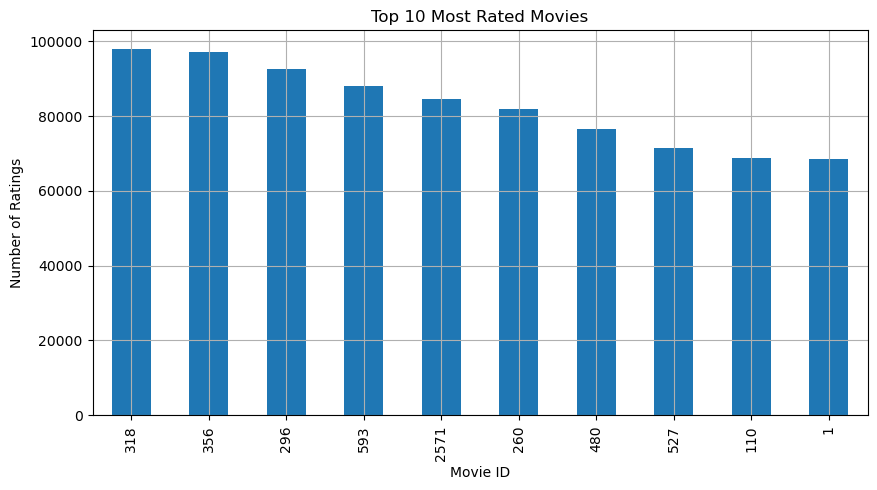

In [17]:
top_movies = ratings_per_movie.sort_values(ascending=False).head(10)
top_movies.plot(kind='bar', figsize=(10, 5))
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.grid(True)
plt.show()

## 6. Top 10 Movies by Average Rating
Lists the 10 movies with the highest average ratings.

In [18]:
avg_ratings = df.groupby('movieId')['rating'].mean()
top_avg_movies = avg_ratings.sort_values(ascending=False).head(10)
print(top_avg_movies)

movieId
169338    5.0
187729    5.0
172149    5.0
160966    5.0
134387    5.0
98437     5.0
134433    5.0
172151    5.0
134605    5.0
134633    5.0
Name: rating, dtype: float64


## 7. Matrix Sparsity Insight
Helps evaluate the density of the dataset.

In [19]:
n_ratings = len(df)
n_possible = df['userId'].nunique() * df['movieId'].nunique()
sparsity = 1 - n_ratings / n_possible
print(f"Matrix sparsity: {sparsity:.4f}")

Matrix sparsity: 0.9982


!! We still need to adjust our preprocess dataset. Now I just train my model with 100,000 samples.

In [103]:
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from sklearn.model_selection import train_test_split as sklearn_train_test_split

#sample_size = 100000
df_reduced = df.iloc[:100000, :]
print("Shape:", df_reduced.shape)

train_val_df, test_df = sklearn_train_test_split(df_reduced, test_size=0.2, random_state=42)
# Define rating scale
reader = Reader(rating_scale=(0.5, 5.0))

# Create Surprise dataset
train_val_set = Dataset.load_from_df(train_val_df[['userId', 'movieId', 'rating']], reader)
test_set = list(zip(test_df['userId'], test_df['movieId'], test_df['rating']))

# train_val_set, test_set
cv = KFold(n_splits=5, random_state=42, shuffle=True)
cross_validate(NormalPredictor(), train_val_set, cv=cv, return_train_measures=True)

Shape: (100000, 4)


{'test_rmse': array([1.50557217, 1.50689835, 1.49351332, 1.48811629, 1.50799372]),
 'train_rmse': array([1.50394187, 1.49902595, 1.50401484, 1.50124222, 1.49758652]),
 'test_mae': array([1.204237  , 1.20059629, 1.19727718, 1.18395267, 1.19937966]),
 'train_mae': array([1.1991595 , 1.19740522, 1.1976984 , 1.19571447, 1.19374802]),
 'fit_time': (0.12476325035095215,
  0.11483120918273926,
  0.1226966381072998,
  0.10172200202941895,
  0.13254094123840332),
 'test_time': (0.14487791061401367,
  0.059027910232543945,
  0.07577228546142578,
  0.0781548023223877,
  0.0630347728729248)}

2.1
We selected KNNBaseline as our neighborhood-based model, which is a basic collaborative filtering algorithm taking into account a baseline rating. This allows it to correct for user and item-specific biases, making the predictions more robust on sparse rating datasets.
We first evaluated this model with default configuration (k=40, min_k=1, the Pearson baseline similarity, and 'user_based' is True). Then, wWe comparde it againsd the NormalPredicto. Later, we manually tuned models ando evaluatde improvement in RMSE


In [104]:
import numpy as np
import pandas as pd
import seaborn as sns
from surprise import KNNBaseline

In [106]:
cross_validate(KNNBaseline(verbose=False), train_val_set, cv=cv, return_train_measures=True)

{'test_rmse': array([0.96034214, 0.97795503, 0.95825851, 0.95774891, 0.96551979]),
 'train_rmse': array([0.6677007 , 0.66518781, 0.66773559, 0.66731165, 0.66731287]),
 'test_mae': array([0.73606179, 0.74115218, 0.73327436, 0.72608984, 0.73315333]),
 'train_mae': array([0.49178861, 0.48978865, 0.49140195, 0.49222234, 0.49199495]),
 'fit_time': (0.4704732894897461,
  0.3834352493286133,
  0.4247269630432129,
  0.3353745937347412,
  0.4014725685119629),
 'test_time': (1.3768250942230225,
  1.2205636501312256,
  1.2989163398742676,
  1.0321018695831299,
  1.0050017833709717)}

In [107]:
rmse_NormalPredictor_array = np.array([1.50557217, 1.50689835, 1.49351332, 1.48811629, 1.50799372])
rmse_KNNBaseline_array = np.array([0.96034214, 0.97795503, 0.95825851, 0.95774891, 0.96551979])

print('Average RMSE NormalPredictor:', round(np.mean(rmse_NormalPredictor_array), 4))
print('Average RMSE KNNBaseline:', round(np.mean(rmse_KNNBaseline_array), 4))

Average RMSE NormalPredictor: 1.5004
Average RMSE KNNBaseline: 0.964


2.2
According to the result above, we could say the KNNBaseine model is better than NormalPredictor. 
To improve the results of the KNNBaseline algorithms, we performed 5-fold cross-validation using different hyperparameters. We changed the hyperparameters based on the default setting.
For the model_a, we changed the number of k-neighbors to 30 and different similarity method to see performance.
For the model_b, we used the bigger min_k to avoid underfit. We also tried item_based to see the difference.
In the model_c, we set a strict condition by narrowing down the number of k-neighbors and made min_k much greater.
Finally, we compared three models' RMSE.

In [108]:
kNNmodel_a = cross_validate(KNNBaseline(k=30, min_k=1, sim_options = {"name": "cosine","user_based": True}, verbose=False), train_val_set, cv=cv, return_train_measures=True)
kNNmodel_a

{'test_rmse': array([0.96577462, 0.98148722, 0.96223301, 0.96277891, 0.97116789]),
 'train_rmse': array([0.79584492, 0.79151081, 0.7956617 , 0.79606512, 0.79484348]),
 'test_mae': array([0.74227687, 0.74579625, 0.73776629, 0.73255393, 0.74018356]),
 'train_mae': array([0.59325071, 0.59057788, 0.59290197, 0.59454932, 0.59324363]),
 'fit_time': (0.5167768001556396,
  0.5451517105102539,
  0.5197727680206299,
  0.6894042491912842,
  0.4795677661895752),
 'test_time': (1.2941949367523193,
  1.0598812103271484,
  0.9850740432739258,
  1.21923828125,
  1.2397313117980957)}

In [109]:
kNNmodel_b = cross_validate(KNNBaseline(k=30, min_k=3, sim_options = {"name": "pearson_baseline","user_based": False}, verbose=False), train_val_set, cv=cv, return_train_measures=True)
kNNmodel_b

{'test_rmse': array([0.93784208, 0.94380558, 0.92645747, 0.93180253, 0.93200851]),
 'train_rmse': array([0.33018817, 0.3292259 , 0.33246767, 0.33409538, 0.33238934]),
 'test_mae': array([0.71563672, 0.71444897, 0.70891768, 0.70546828, 0.70503667]),
 'train_mae': array([0.19489627, 0.19397379, 0.19561732, 0.19621154, 0.19629645]),
 'fit_time': (5.635233163833618,
  4.910212278366089,
  5.156888008117676,
  5.184803247451782,
  5.221667528152466),
 'test_time': (4.918436288833618,
  5.091813325881958,
  4.5440874099731445,
  4.313037872314453,
  4.587922811508179)}

In [110]:
kNNmodel_c = cross_validate(KNNBaseline(k=10, min_k=5, sim_options = {"name": "pearson_baseline","user_based": True}, verbose=False), train_val_set, cv=cv, return_train_measures=True)
kNNmodel_c

{'test_rmse': array([0.94861261, 0.96347826, 0.94210449, 0.94294263, 0.94554305]),
 'train_rmse': array([0.50913293, 0.50462733, 0.50950967, 0.51242521, 0.50933748]),
 'test_mae': array([0.72700089, 0.73224606, 0.72143452, 0.71913688, 0.7199431 ]),
 'train_mae': array([0.29134292, 0.28899709, 0.29240188, 0.29350228, 0.29214299]),
 'fit_time': (0.6738982200622559,
  0.7000999450683594,
  0.49524474143981934,
  0.7823452949523926,
  0.4788670539855957),
 'test_time': (1.0878348350524902,
  0.819019079208374,
  0.6713466644287109,
  1.156040906906128,
  0.6830766201019287)}

In [111]:
rmse_kNNmodel_a_array = np.array([0.96577462, 0.98148722, 0.96223301, 0.96277891, 0.97116789])
rmse_kNNmodel_b_array = np.array([0.93784208, 0.94380558, 0.92645747, 0.93180253, 0.93200851])
rmse_kNNmodel_c_array = np.array([0.94861261, 0.96347826, 0.94210449, 0.94294263, 0.94554305])

print('Average RMSE KNNBaseline model_a:', round(np.mean(rmse_kNNmodel_a_array), 4))
print('Average RMSE KNNBaseline model_b:', round(np.mean(rmse_kNNmodel_b_array), 4))
print('Average RMSE KNNBaseline model_c:', round(np.mean(rmse_kNNmodel_c_array), 4))

Average RMSE KNNBaseline model_a: 0.9687
Average RMSE KNNBaseline model_b: 0.9344
Average RMSE KNNBaseline model_c: 0.9485


2.3
We also used GridSearch to find the optimal hyperparameters. However, we found that the result of RMSE was not better than model_b. As a result, we selected model_b as our best model to test.

In [112]:
from surprise.model_selection import GridSearchCV
param_grid_KNN = {'k': [20, 30, 40, 50, 60], 'min_k': [1, 3, 5, 7, 10], "name": ["cosine","msd","pearson","pearson_baseline"],'user_based': [True, False], 'verbose': [False]}
grid_search_KNN = GridSearchCV(KNNBaseline, param_grid_KNN, measures=["rmse"], cv=5)
grid_search_KNN.fit(train_val_set)

best_model = grid_search_KNN.best_estimator['rmse']

# Return the best RMSE score
print(round(grid_search_KNN.best_score['rmse'], 4))

# Return the combination of parameters that gave the best RMSE score
print(grid_search_KNN.best_params['rmse'])

0.9428
{'k': 40, 'min_k': 10, 'name': 'cosine', 'user_based': True, 'verbose': False}


In [113]:
from surprise import KNNBaseline
kNNmodel_optimal = cross_validate(KNNBaseline(k=40, min_k=10, sim_options = {"name": "cosine","user_based": True}, verbose=False), train_val_set, cv=cv, return_train_measures=True)
kNNmodel_optimal

{'test_rmse': array([0.94666081, 0.95900361, 0.9389275 , 0.94040177, 0.9462139 ]),
 'train_rmse': array([0.86648678, 0.86331718, 0.86745144, 0.86806476, 0.86600362]),
 'test_mae': array([0.72902299, 0.73202277, 0.7233308 , 0.71953734, 0.72412807]),
 'train_mae': array([0.66209465, 0.66006714, 0.66259018, 0.66430016, 0.66244582]),
 'fit_time': (0.48473119735717773,
  0.39911651611328125,
  0.5173797607421875,
  0.41524600982666016,
  0.5551304817199707),
 'test_time': (1.185502052307129,
  1.1721172332763672,
  1.3140838146209717,
  0.8856205940246582,
  0.975348949432373)}

In [114]:
rmse_kNNmodel_optimal_array = np.array([0.94666081, 0.95900361, 0.9389275 , 0.94040177, 0.9462139 ])

print('Average RMSE KNNBaseline model_optimal:', round(np.mean(rmse_kNNmodel_optimal_array), 4))

Average RMSE KNNBaseline model_optimal: 0.9462


2.4 
Now, we evaluated the best model’s performance using two types of RMSE (Root Mean Squared Error):



1. **Cross-validation RMSE (from `cross_validate`)**  
   This RMSE reflects the model’s accuracy within the training data through 5-fold cross-validationns.  
   However, this value does not represent how well the model performs on completely unseen d
2. **Final test RMSE (from `test_set`)**  
   We trained our model on the entire training set and evaluated it on a separate test set.   
   This RMSE indicates the model’s **generalization ability** — how well it performs on unseen data.en

The result showed the similar outputs between two RMSEs, which means the model did not overfit.alization.

In [131]:
best_model = KNNBaseline(k=30, min_k=3, sim_options = {"name": "pearson_baseline","user_based": False}, verbose=False)
#RMSE from 5-fold CV
cross_validate(best_model, train_val_set, cv=cv, return_train_measures=True)
trainset = train_val_set.build_full_trainset()
best_model.fit(trainset)

prediction = best_model.test(test_set)

from surprise import accuracy
# RMSE from test set
accuracy.rmse(prediction)

RMSE: 0.9283


0.9282727687246203

2.5
To evaluate the generalization of the model, we plotted the predicted rating distributions for both the train and test sets. As shown in the chart, both distributions appear similar, indicating that the model generalizes.

user: 790        item: 165        r_ui = 3.00   est = 3.41   {'actual_k': 29, 'was_impossible': False}


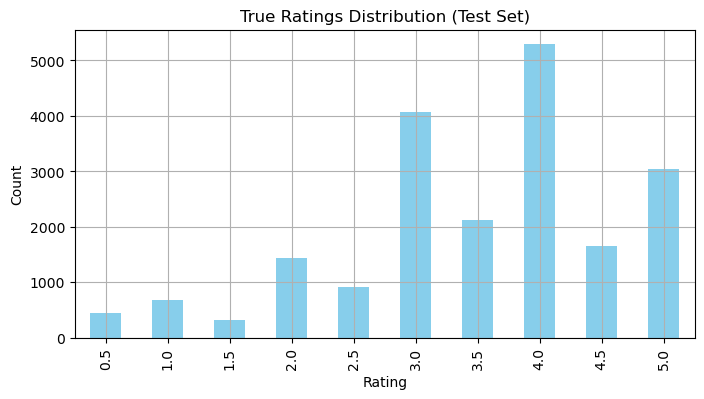

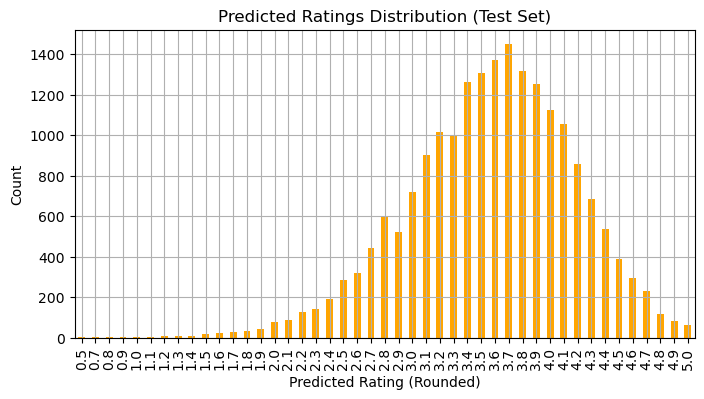

In [132]:
import matplotlib.pyplot as plt
import pandas as pd
pred = prediction[0]
print(pred)

pred_df = pd.DataFrame({
    'userId': [pred.uid for pred in prediction],
    'movieId': [pred.iid for pred in prediction],
    'true_rating': [pred.r_ui for pred in prediction],
    'pred_rating': [pred.est for pred in prediction]
})

# Real test
plt.figure(figsize=(8, 4))
pred_df['true_rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("True Ratings Distribution (Test Set)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Prediction
plt.figure(figsize=(8, 4))
pred_df['pred_rating'].round(1).value_counts().sort_index().plot(kind='bar', color='orange')
plt.title("Predicted Ratings Distribution (Test Set)")
plt.xlabel("Predicted Rating (Rounded)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

2.6 We trained and tested our model twice to make sure the ability of generalization ability.

In [133]:
train_val_df2, test_df2 = sklearn_train_test_split(df_reduced, test_size=0.2, random_state=123)
reader = Reader(rating_scale=(0.5, 5.0))
train_val_set2 = Dataset.load_from_df(train_val_df2[['userId', 'movieId', 'rating']], reader)
test_set2 = list(zip(test_df2['userId'], test_df2['movieId'], test_df2['rating']))

best_model = KNNBaseline(k=30, min_k=3, sim_options = {"name": "pearson_baseline","user_based": False}, verbose=False)
#RMSE from 5-fold CV
cross_validate(best_model, train_val_set2, cv=cv, return_train_measures=True)
trainset2 = train_val_set2.build_full_trainset()
best_model.fit(trainset2)
prediction_2 = best_model.test(test_set2)
#RMSE from test set:
accuracy.rmse(prediction_2)

RMSE: 0.9304


0.9303528237670576

user: 408        item: 1084       r_ui = 3.00   est = 3.48   {'actual_k': 30, 'was_impossible': False}


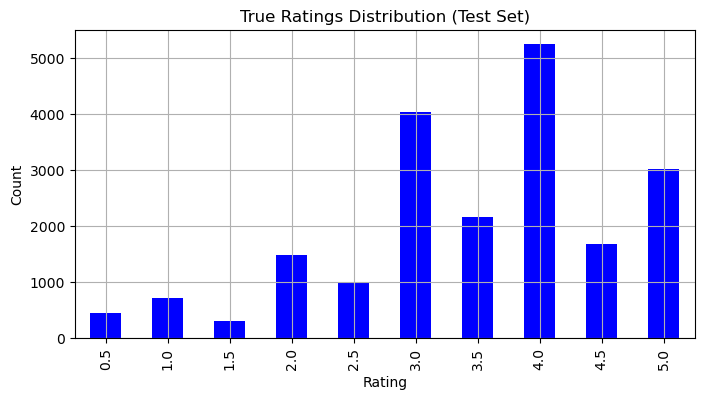

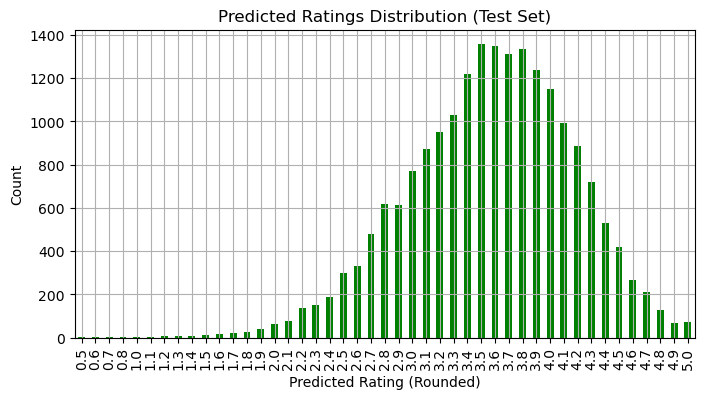

In [135]:
import matplotlib.pyplot as plt
import pandas as pd
pred2 = prediction_2[0]
print(pred2)

pred_df2 = pd.DataFrame({
    'userId': [pred2.uid for pred2 in prediction_2],
    'movieId': [pred2.iid for pred2 in prediction_2],
    'true_rating': [pred2.r_ui for pred2 in prediction_2],
    'pred_rating': [pred2.est for pred2 in prediction_2]
})

# Real test
plt.figure(figsize=(8, 4))
pred_df2['true_rating'].value_counts().sort_index().plot(kind='bar', color='blue')
plt.title("True Ratings Distribution (Test Set)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Prediction
plt.figure(figsize=(8, 4))
pred_df2['pred_rating'].round(1).value_counts().sort_index().plot(kind='bar', color='green')
plt.title("Predicted Ratings Distribution (Test Set)")
plt.xlabel("Predicted Rating (Rounded)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

2.7 KNN Conclusion

On both tests(2.5 & 2.6), two predicted distributions closely followed the true distribution. It indicated that the model was able to learn the underlying rating patterns. Also, those distributions are similar between two tests, which means the model was not overfitting to a specific training dataset.